In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\domin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

In [3]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


We are dealing with circular data such as column 'day' and 'wind direction'. We want to transform them using sin() and cos() functions. This helps capture the cyclical relationship in a continuous way, ensuring that values at the “ends” of the cycle are close together.

In [4]:
df_train['day'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

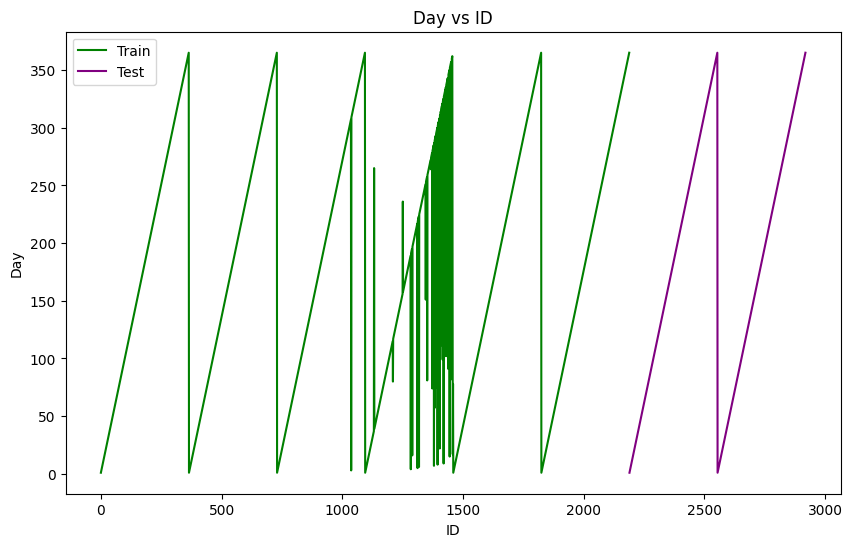

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

We were expecting a circular pattern in the plot above. We can see that the days are not in order, but we can see that the pattern is cyclical. We can repair this by transforming the 'day' column.

In [6]:
# Transform day column so that id matches the day
df_train['day_repaired'] = df_train['id'] % 365

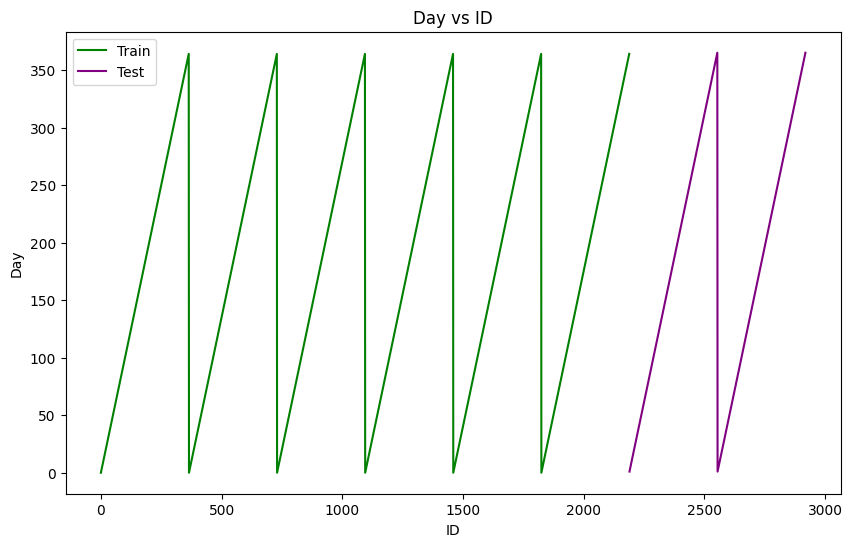

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(df_train['id'], df_train['day_repaired'], label='Train', color='green')
plt.plot(df_test['id'], df_test['day'], label='Test', color='purple')
plt.title('Day vs ID')
plt.xlabel('ID')
plt.ylabel('Day')
plt.legend()
plt.show()

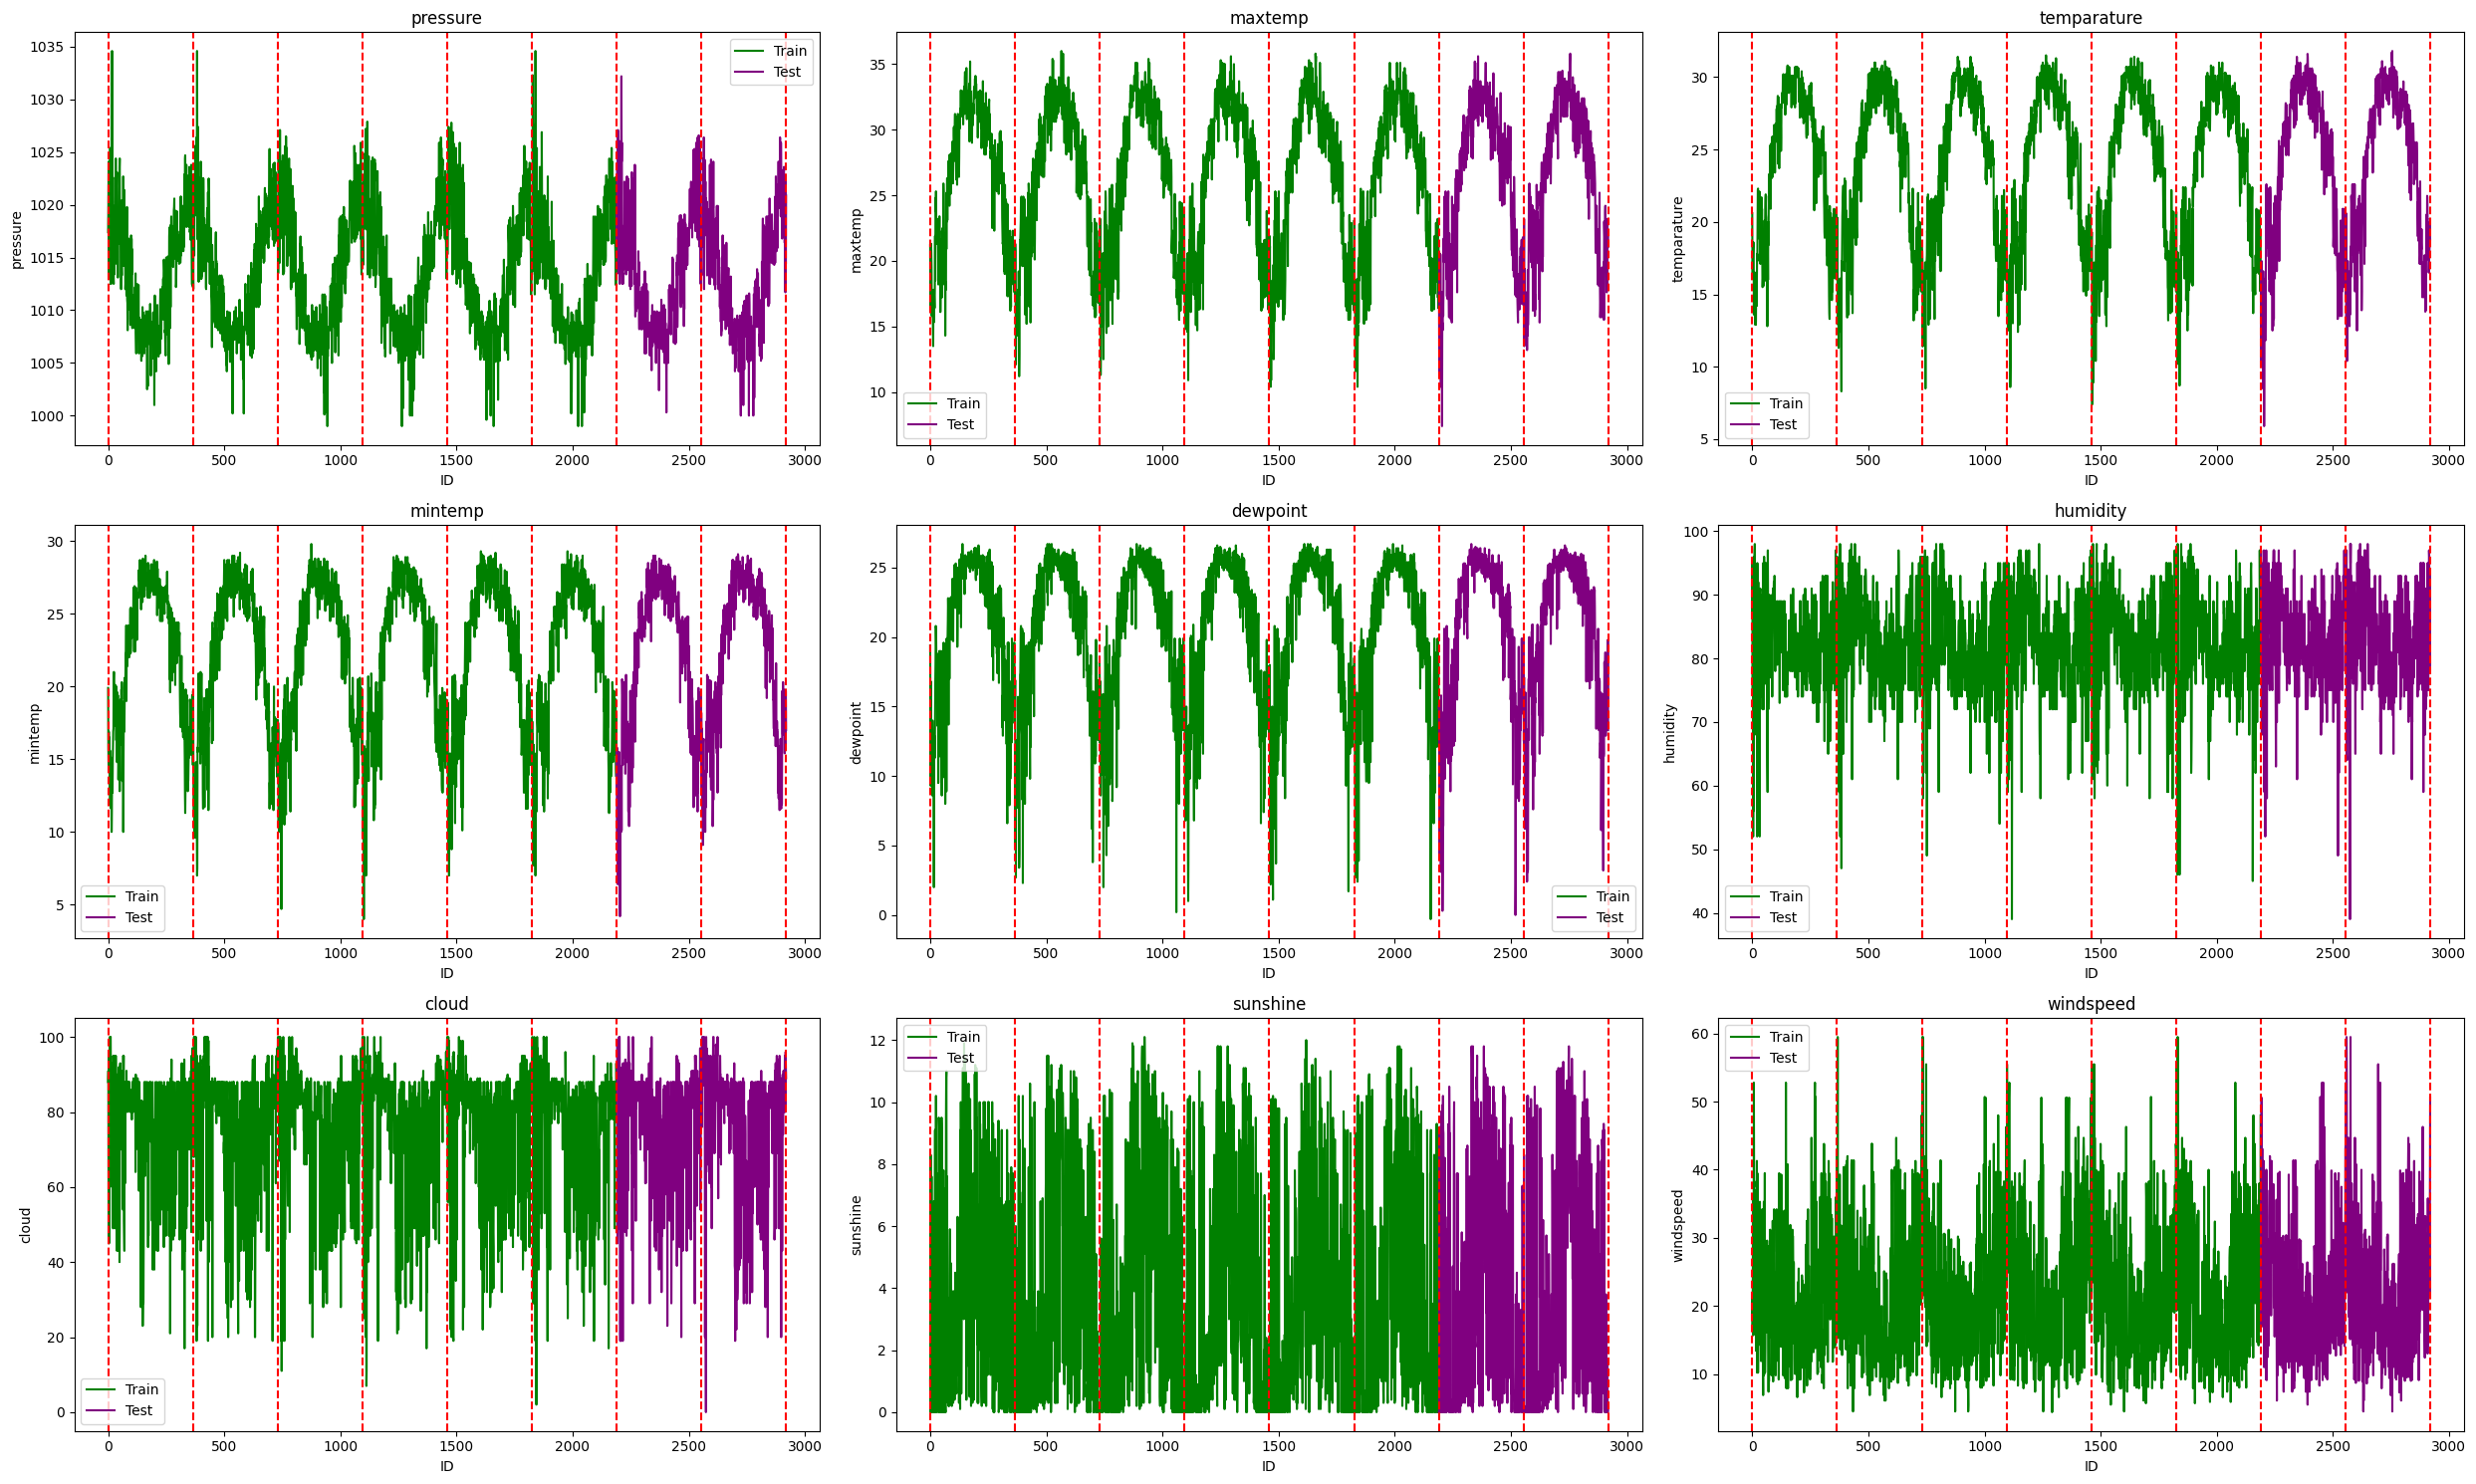

In [8]:
feature_list = [item for item in df_train.columns if item not in ['id', 'day', 'day_repaired', 'rainfall', 'winddirection']]

fig, axes = plt.subplots(3, 3, figsize=(25, 15))
axes = axes.flatten()
lines = [x for x in range(0, max(df_test['id']) + 364, 365)]
for i, feature in enumerate(feature_list):
    axes[i].plot(df_train['id'], df_train[feature], color='green')
    axes[i].plot(df_test['id'], df_test[feature], color='purple')
    for x in lines:
        axes[i].axvline(x=x, color='red', linestyle='--')
    axes[i].set_title(feature)
    axes[i].set_xlabel('ID')
    axes[i].set_ylabel(feature)
    axes[i].legend(['Train', 'Test'])

plt.tight_layout()
plt.show()

We see that the pattern is cyclical. Now we can transform the 'day' column.

In [9]:
def transform_circular(data, column):
    new_data = data.copy()
    new_data[column + '_sin'] = np.sin(2 * np.pi * new_data[column] / max(new_data[column]))
    new_data[column + '_cos'] = np.cos(2 * np.pi * new_data[column] / max(new_data[column]))
    return new_data

In [10]:
train = transform_circular(df_train, 'day_repaired')
train = transform_circular(train, 'winddirection')
train.drop(['id', 'day', 'day_repaired', 'winddirection'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,day_repaired_sin,day_repaired_cos,winddirection_sin,winddirection_cos
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,0.000000,1.000000,0.951057,0.309017
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,0.017261,0.999851,0.866025,0.500000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,0.034516,0.999404,0.994522,0.104528
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,0.051761,0.998659,0.951057,0.309017
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,0.068991,0.997617,0.743145,0.669131


Ostateczna wersja danych to 'train'.

## Combinations of columns

In [11]:
import itertools

In [12]:
def generate_combinations(df, exclude_columns=[]):
    selected_columns = [col for col in df.columns if col not in exclude_columns]

    new_columns = {}
    
    for n in range(2, 3):
        for cols in itertools.combinations(selected_columns, n):
            col_combination = '_'.join(cols)
    
            # Addition
            new_columns[f'{col_combination}_plus'] = df[list(cols)].sum(axis=1)
    
            # Subtraction
            if n == 2:
                new_columns[f'{cols[0]}_minus_{cols[1]}'] = df[cols[0]] - df[cols[1]]
                new_columns[f'{cols[1]}_minus_{cols[0]}'] = df[cols[1]] - df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_minus_{pair[1]}'] = df[pair[0]] - df[pair[1]]
                    new_columns[f'{pair[1]}_minus_{pair[0]}'] = df[pair[1]] - df[pair[0]]
    
            # Multiplication
            new_columns[f'{col_combination}_times'] = df[list(cols)].prod(axis=1)
    
            # Division
            if n == 2:
                new_columns[f'{cols[0]}_div_{cols[1]}'] = df[cols[0]] / df[cols[1]]
                new_columns[f'{cols[1]}_div_{cols[0]}'] = df[cols[1]] / df[cols[0]]
            else:
                for pair in itertools.combinations(cols, 2):
                    new_columns[f'{pair[0]}_div_{pair[1]}'] = df[pair[0]] / df[pair[1]]
                    new_columns[f'{pair[1]}_div_{pair[0]}'] = df[pair[1]] / df[pair[0]]
    
    df_new = pd.DataFrame(new_columns, index=df.index)
    
    df_comb = pd.concat([df, df_new], axis=1)
    df_comb.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_comb.fillna(0, inplace=True)
    return df_comb

In [13]:
train_combinations = generate_combinations(train, exclude_columns=['rainfall'])
train_combinations.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,...,winddirection_cos_minus_day_repaired_cos,day_repaired_cos_winddirection_cos_times,day_repaired_cos_div_winddirection_cos,winddirection_cos_div_day_repaired_cos,winddirection_sin_winddirection_cos_plus,winddirection_sin_minus_winddirection_cos,winddirection_cos_minus_winddirection_sin,winddirection_sin_winddirection_cos_times,winddirection_sin_div_winddirection_cos,winddirection_cos_div_winddirection_sin
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1,...,-0.690983,0.309017,3.236068,0.309017,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1,...,-0.499851,0.499926,1.999702,0.500074,1.366025,0.366025,-0.366025,0.433013,1.732051,0.577350
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,1,...,-0.894876,0.104466,9.561072,0.104591,1.099050,0.889993,-0.889993,0.103956,9.514364,0.105104
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,...,-0.689642,0.308603,3.231730,0.309432,1.260074,0.642040,-0.642040,0.293893,3.077684,0.324920
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,...,-0.328487,0.667536,1.490916,0.670729,1.412275,0.074014,-0.074014,0.497261,1.110613,0.900404


final data to use is 'train_combinations'

## Adding data from the previous days

In [14]:
def add_prev_days(df):
    """
    This function creates `df_prev` dataframe from `df`, adding weather features from previous days. 
    It adds 3 types of new columns: 
    weather features from the previous day, 
    the average values of features from the previous two days, 
    and the average values from the previous three days. 

    Parameters:
    df (pd.DataFrame): Input table, which contains the following columns:
        - 'id'
        - 'day'
        - 'pressure' 
        - 'maxtemp'	
        - 'temperature'	
        - 'mintemp'	
        - 'dewpoint' 
        - 'humidity' 
        - 'cloud' 
        - 'sunshine' 
        - 'winddirection' 
        - 'windspeed' 
        - 'rainfall'

    Returns:
    df_prev (pd.DataFrame): A new table containing the original data and features from the previous days.
    """

    df_prev = df.copy()
    
    columns_to_drop = [col for col in df.columns if any(keyword in col for keyword in ['id', 'day', 'day_repaired'])]
    
    df_shifted1 = df_prev.shift(1)
    df_shifted1.drop(columns_to_drop, axis=1, inplace=True)

    df_prev = pd.concat([df_prev, df_shifted1.add_prefix("prev1_")], axis=1)

    columns_to_drop = [col for col in df_shifted1.columns if any(keyword in col for keyword in ['winddirection', 'rainfall'])]

    df_shifted1.drop(columns_to_drop, axis=1, inplace=True)

    columns_to_drop = [col for col in df.columns if any(keyword in col for keyword in ['id', 'day', 'day_repaired', 'winddirection', 'rainfall'])]

    df_shifted2 = df.shift(2)
    df_shifted2.drop(columns_to_drop, axis=1, inplace=True)

    df_shifted3 = df.shift(3)
    df_shifted3.drop(columns_to_drop, axis=1, inplace=True)

    df_avg2 = pd.concat([df_shifted1, df_shifted2]).groupby(level=0).mean()
    df_avg2[(df_shifted1.isna()) | (df_shifted2.isna())] = np.nan
    df_avg2 = df_avg2.add_prefix("avg2_")
    df_avg2 = df_avg2.round(1)

    df_avg3 = pd.concat([df_shifted1, df_shifted2, df_shifted3]).groupby(level=0).mean()
    df_avg3[(df_shifted1.isna()) | (df_shifted2.isna()) | (df_shifted3.isna())] = np.nan
    df_avg3 = df_avg3.add_prefix("avg3_")
    df_avg3 = df_avg3.round(1)

    df_prev = pd.concat([df_prev, df_avg2, df_avg3], axis=1)
    # removing the first three records that lack information from the previous three days
    df_prev = df_prev.dropna().reset_index(drop=True)

    return df_prev

In [15]:
train_prev = add_prev_days(train_combinations)
train_prev

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,rainfall,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1,...,-56.3,1452.4,4.0,0.3,22.2,-15.9,15.9,56.4,0.2,5.9
1,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0,...,-52.5,2075.2,3.1,0.3,28.0,-22.4,22.4,50.1,0.2,0.7
2,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,15.7,1,...,-36.2,1782.9,2.4,0.4,30.1,-22.2,22.2,79.8,0.2,3.0
3,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,28.4,0,...,-48.3,1923.2,3.2,0.4,26.6,-24.2,24.2,29.8,0.0,2.3
4,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,52.8,1,...,-34.4,1231.4,2.9,0.5,26.7,-19.2,19.2,101.7,0.1,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2182,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,22.1,1,...,-55.7,2677.3,2.9,0.4,32.2,-29.8,29.8,41.0,0.0,11.5
2183,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,35.3,1,...,-56.4,2609.9,3.0,0.4,31.1,-29.4,29.4,31.1,0.0,78.9
2184,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,32.9,1,...,-58.7,2581.3,3.1,0.3,29.4,-29.3,29.3,0.7,0.0,73.7
2185,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,18.0,1,...,-54.9,2550.1,3.0,0.4,31.8,-28.4,28.4,55.6,0.1,75.9


final data to use is 'train_prev'

In [22]:
X_train_prev = train_prev.drop('rainfall', axis=1)
Y_train_prev = train_prev['rainfall']
X_train_prev.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,day_repaired_sin,...,avg3_windspeed_minus_cloud,avg3_cloud_windspeed_times,avg3_cloud_div_windspeed,avg3_windspeed_div_cloud,avg3_sunshine_windspeed_plus,avg3_sunshine_minus_windspeed,avg3_windspeed_minus_sunshine,avg3_sunshine_windspeed_times,avg3_sunshine_div_windspeed,avg3_windspeed_div_sunshine
0,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,0.051761,...,-56.3,1452.4,4.0,0.3,22.2,-15.9,15.9,56.4,0.2,5.9
1,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,0.068991,...,-52.5,2075.2,3.1,0.3,28.0,-22.4,22.4,50.1,0.2,0.7
2,1022.7,20.6,18.6,16.5,12.5,79.0,81.0,0.0,15.7,0.086200,...,-36.2,1782.9,2.4,0.4,30.1,-22.2,22.2,79.8,0.2,3.0
3,1022.8,19.5,18.4,15.3,11.3,56.0,46.0,7.6,28.4,0.103384,...,-48.3,1923.2,3.2,0.4,26.6,-24.2,24.2,29.8,0.0,2.3
4,1019.7,15.8,13.6,12.7,11.8,96.0,100.0,0.0,52.8,0.120537,...,-34.4,1231.4,2.9,0.5,26.7,-19.2,19.2,101.7,0.1,3.5


# PCA

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Explained variance ratio for each component: [0.35757947 0.11355996 0.06245518 0.05294064 0.03365463 0.02759114
 0.020142   0.0170972  0.01475763 0.01425884 0.01326349 0.01272944
 0.01235052 0.01127141 0.01084505 0.01070501 0.01037537 0.00943977
 0.00925156 0.00883195 0.00876958 0.00827636 0.00813281 0.00797416
 0.00753973 0.00736718 0.00711131 0.00671438 0.00620293 0.00586402
 0.00557958]
Total variance explained by the components: 0.9026323296958575
Transformed data (first 5 rows): 
[[-2.37735621e+01 -6.97690194e+00  1.89588814e+01 -1.46217953e+00
   4.38512483e+00 -3.63168705e-01 -4.92950704e+00  5.15634354e+00
  -6.04357109e+00  2.94739488e+00  1.73546393e+00  3.34154958e+00
  -4.64622755e+00 -1.20616780e+00 -2.18459476e-01  2.77579357e+00
  -2.60518881e-01 -3.32223624e+00 -1.88596702e+00  2.47507028e+00
   1.65118304e+00  6.77071596e-01 -1.11866826e+00  9.01876490e-01
  -2.53256966e+00  3.41349835e-01  1.89984619e+00 -2.92771448e+00
  -3.73312423e+00 -5.68760740e-01 -4.45002557e-0

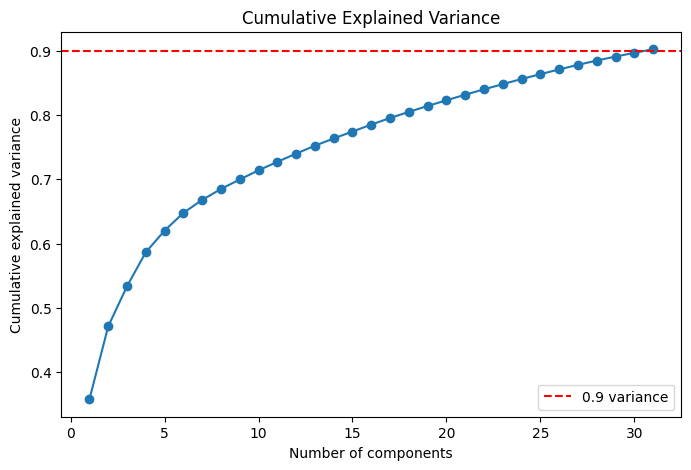

In [32]:
X = X_train_prev

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

var = 0.9
pca = PCA(n_components=var)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio for each component: {pca.explained_variance_ratio_}")
print(f"Total variance explained by the components: {sum(pca.explained_variance_ratio_)}")
print(f"Transformed data (first 5 rows): \n{X_pca[:5]}")

cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=var, color='r', linestyle='--', label=f'{var} variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

# Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_prev, Y_train_prev)

importances = clf.feature_importances_
features_importance = pd.Series(importances, index=X_train_prev.columns).sort_values(ascending=False)

print(features_importance)

dewpoint_cloud_plus              0.026910
humidity_cloud_times             0.022774
cloud_div_pressure               0.022024
humidity_cloud_plus              0.018250
cloud_day_repaired_cos_plus      0.018230
                                   ...   
avg3_maxtemp_div_pressure        0.000000
avg3_mintemp_div_pressure        0.000000
avg2_temparature_div_pressure    0.000000
avg2_maxtemp_div_pressure        0.000000
avg2_dewpoint_div_pressure       0.000000
Length: 1114, dtype: float64


In [28]:
features_importance.head(40)

dewpoint_cloud_plus                0.026910
humidity_cloud_times               0.022774
cloud_div_pressure                 0.022024
humidity_cloud_plus                0.018250
cloud_day_repaired_cos_plus        0.018230
cloud_sunshine_plus                0.016498
pressure_div_cloud                 0.016276
winddirection_cos_minus_cloud      0.016198
cloud_minus_pressure               0.014370
pressure_minus_cloud               0.014177
cloud_winddirection_cos_plus       0.013942
cloud_minus_dewpoint               0.013888
cloud                              0.012798
maxtemp_minus_cloud                0.011856
sunshine_minus_humidity            0.010730
temparature_cloud_plus             0.010478
winddirection_sin_minus_cloud      0.010354
cloud_minus_day_repaired_cos       0.009733
day_repaired_sin_minus_cloud       0.009377
mintemp_cloud_plus                 0.008472
maxtemp_cloud_plus                 0.007638
mintemp_minus_cloud                0.007481
cloud_minus_winddirection_cos   

In [30]:
features_importance.tail(60)

avg2_maxtemp_div_cloud                           1.181830e-04
avg3_dewpoint_div_cloud                          1.174525e-04
avg2_maxtemp_minus_cloud                         1.154759e-04
avg3_mintemp_dewpoint_times                      1.149195e-04
temparature_mintemp_times                        1.145297e-04
avg2_mintemp_div_maxtemp                         1.126749e-04
prev1_pressure_minus_winddirection_cos           1.098546e-04
avg2_temparature_div_mintemp                     1.098378e-04
prev1_rainfall                                   1.073478e-04
avg3_sunshine_div_mintemp                        1.043652e-04
avg3_cloud_minus_temparature                     1.035765e-04
avg2_maxtemp_div_dewpoint                        1.023821e-04
avg2_dewpoint_div_mintemp                        9.483396e-05
temparature_minus_winddirection_sin              9.141257e-05
avg2_sunshine_div_temparature                    8.284963e-05
avg3_dewpoint_div_maxtemp                        8.276497e-05
avg2_win